In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [2]:
#Definimos las direcciones de los archivos

dirq5 = "./data/q5/N256-kIR0.1-kcutoff100-tmax690/"
dirq30 = "./data/q30/N256-kIR0.1-kcutoff100-tmax690/"
dirq200 = "./data/q200/N256-kIR0.25-kcutoff100-tmax690/"
dirq500 = "./data/q500/N256-kIR0.4-kcutoff100-tmax690/"

# Buscamos las bandas de resonancia

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

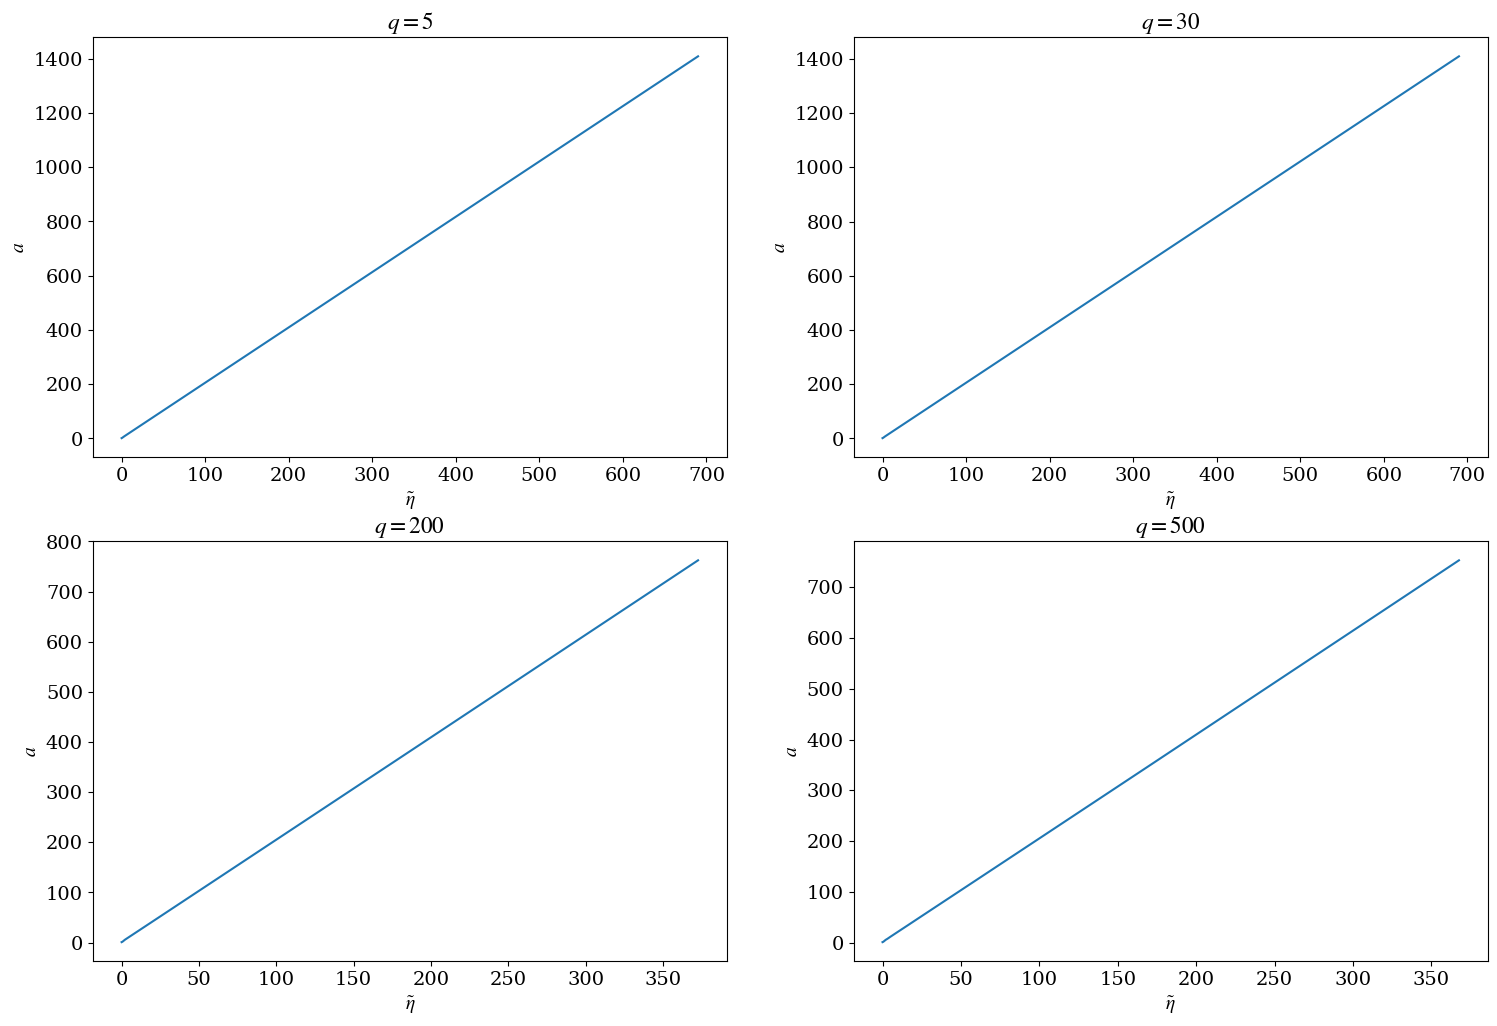

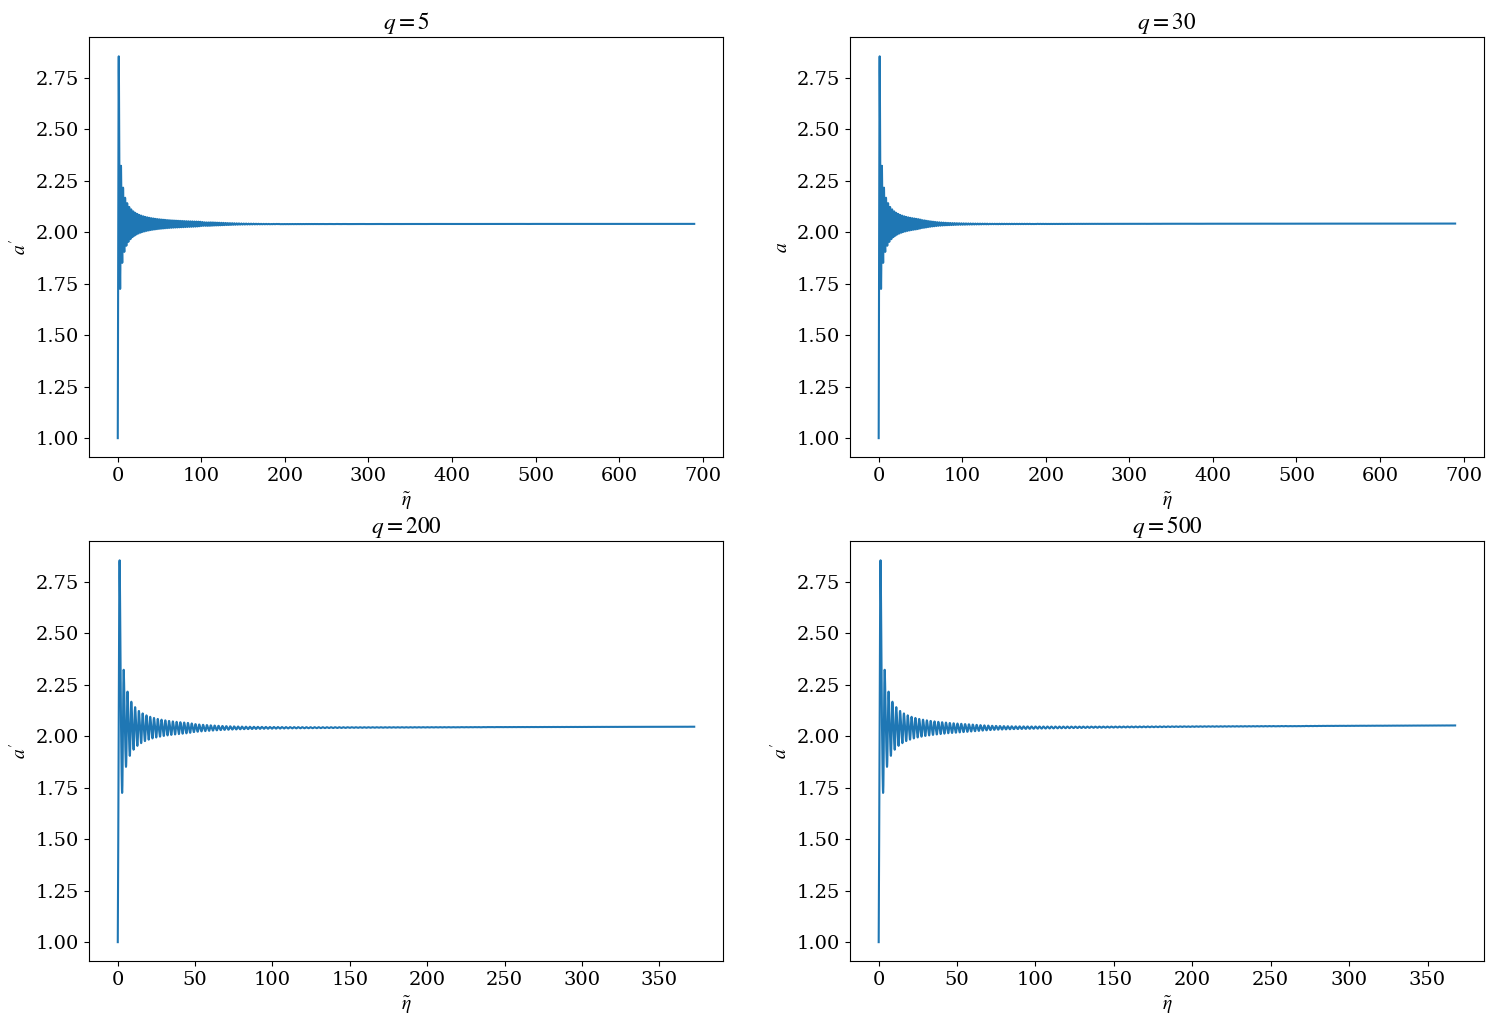

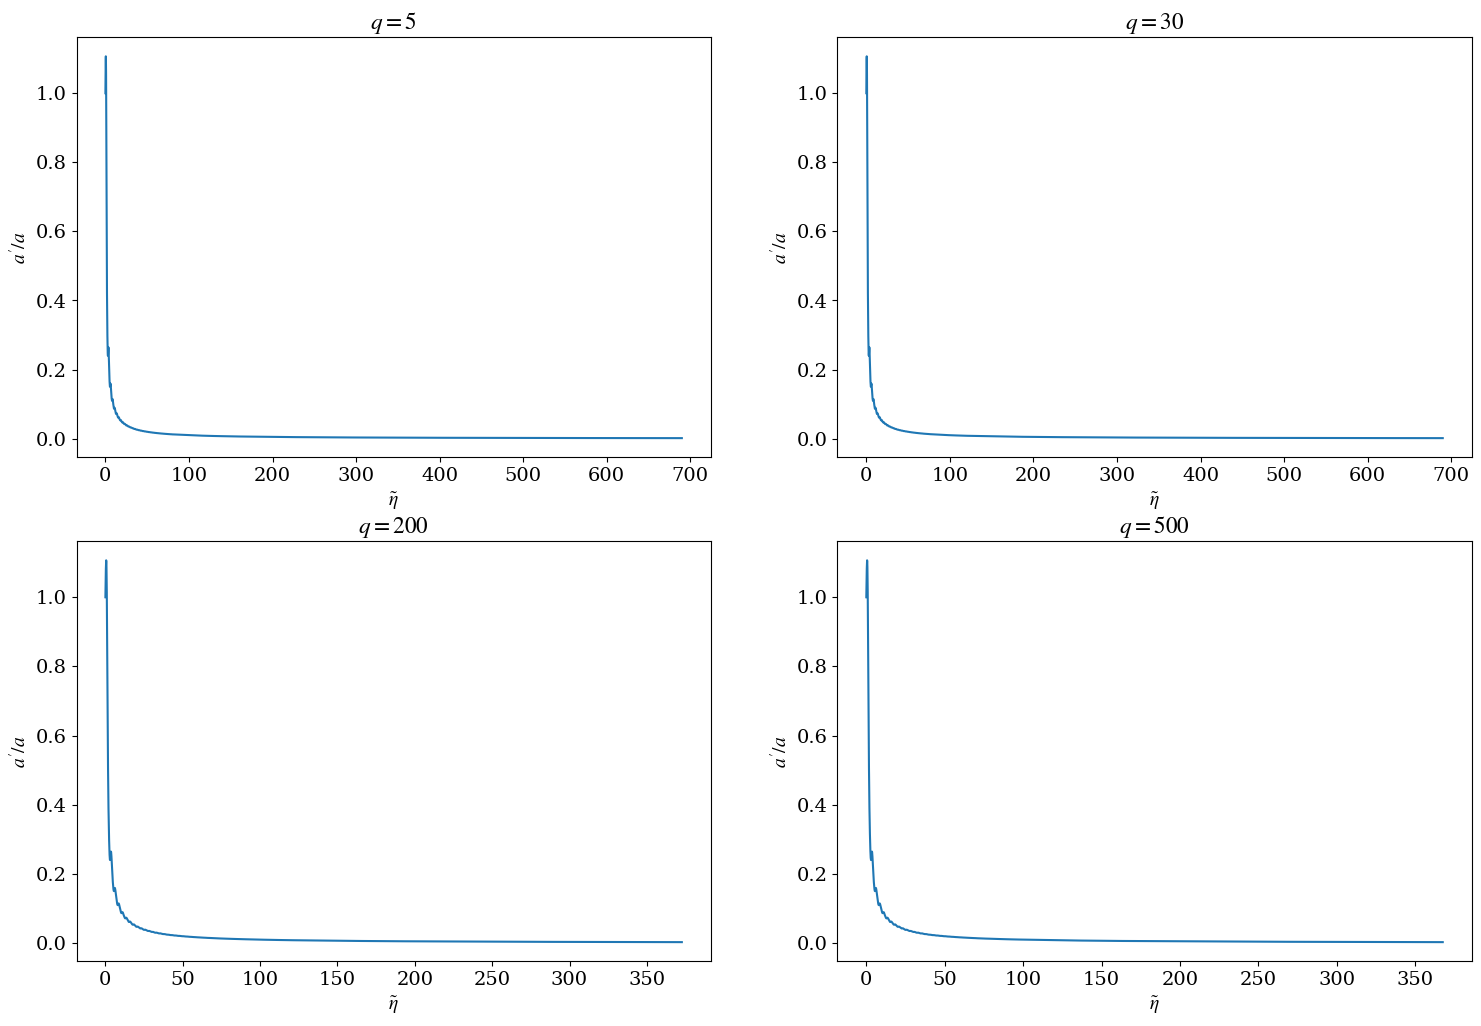

In [3]:
expansion = True

if expansion == True:
    # load the file in aDat
    aDatq5 = np.loadtxt(dirq5 + "average_scale_factor.txt")
    aDatq30 = np.loadtxt(dirq30 + "average_scale_factor.txt")
    aDatq200 = np.loadtxt(dirq200 + "average_scale_factor.txt")
    aDatq500 = np.loadtxt(dirq500 + "average_scale_factor.txt")
    
    #plot a
    plt.figure(figsize=(18, 12))
    
    plt.subplot(2, 2, 1)
    plt.plot(aDatq5[:,0], aDatq5[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$q=5$')

    plt.subplot(2, 2, 2)
    plt.plot(aDatq30[:,0], aDatq30[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$q=30$')

    plt.subplot(2, 2, 3)
    plt.plot(aDatq200[:,0], aDatq200[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$q=200$')

    plt.subplot(2, 2, 4)
    plt.plot(aDatq500[:,0], aDatq500[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$q=500$')

    
    #plot a'
    plt.figure(figsize=(18, 12))
    
    plt.subplot(2, 2, 1)
    plt.plot(aDatq5[:,0], aDatq5[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$q=5$')

    plt.subplot(2, 2, 2)
    plt.plot(aDatq30[:,0], aDatq30[:,2])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$q=30$')

    plt.subplot(2, 2, 3)
    plt.plot(aDatq200[:,0], aDatq200[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$q=200$')

    plt.subplot(2, 2, 4)
    plt.plot(aDatq500[:,0], aDatq500[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$q=500$')
    
    
    #plot a'/a
    plt.figure(figsize=(18, 12))
    
    plt.subplot(2, 2, 1)
    plt.plot(aDatq5[:,0], aDatq5[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$q=5$')

    plt.subplot(2, 2, 2)
    plt.plot(aDatq30[:,0], aDatq30[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$q=30$')

    plt.subplot(2, 2, 3)
    plt.plot(aDatq200[:,0], aDatq200[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$q=200$')

    plt.subplot(2, 2, 4)
    plt.plot(aDatq500[:,0], aDatq500[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$q=500$')

else:
    aDatq5 = None
    aDatq30 = None
    aDatq200 = None
    aDatq500 = None

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [4]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    plt.plot(fldDat[:,0], fldDat[:,1])
    plt.xlabel("$\\tilde\eta$")
    plt.ylabel("$\langle\phi_"+ fldNum +"\\rangle$")
    
    if aDat is not None:
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1])
        plt.xlabel("$\\tilde\eta$")
        plt.ylabel("$a\cdot\langle\phi_"+ fldNum +" \\rangle$")

## Field $0$ (inflaton)

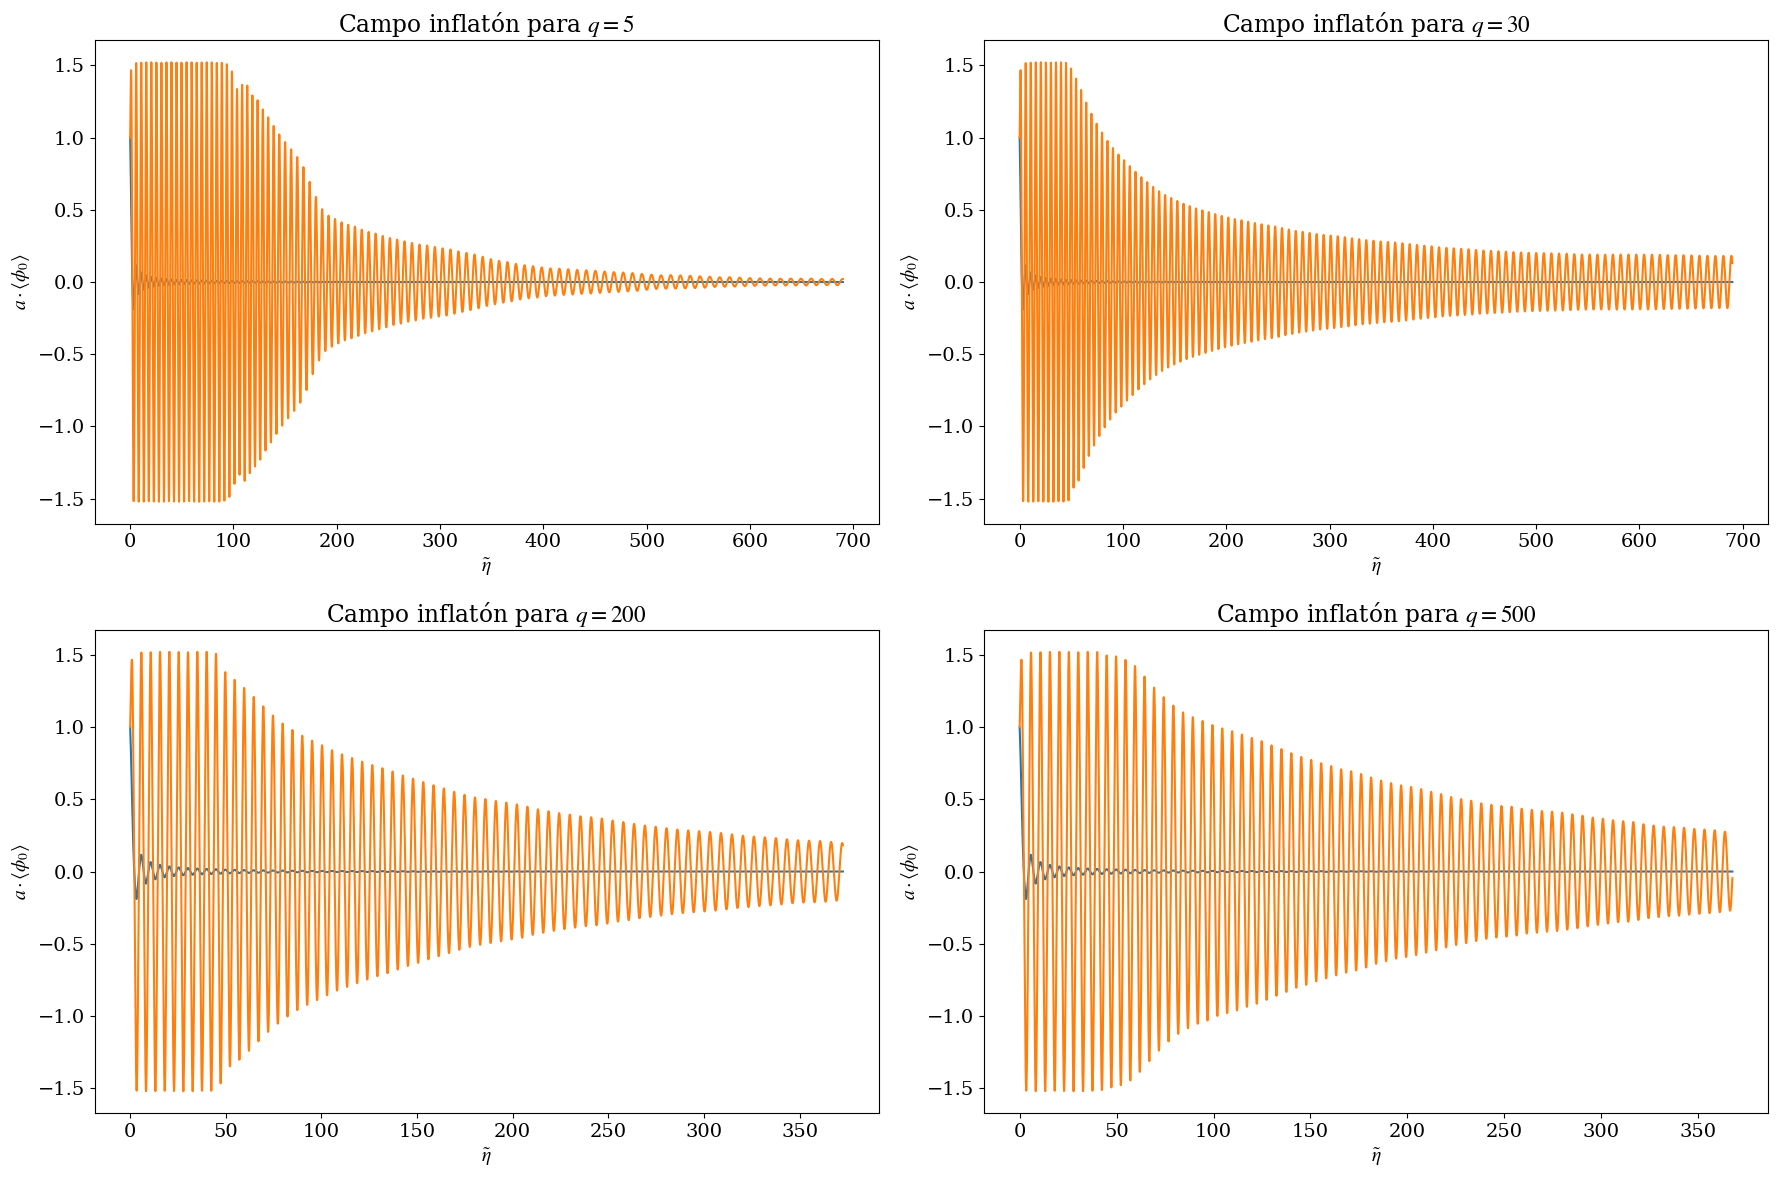

In [5]:
infDatq5 = np.loadtxt(dirq5 + "average_scalar_0.txt")
infDatq30 = np.loadtxt(dirq30 + "average_scalar_0.txt")
infDatq200 = np.loadtxt(dirq200 + "average_scalar_0.txt")
infDatq500 = np.loadtxt(dirq500 + "average_scalar_0.txt")

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plot_fld(infDatq5,"0",aDatq5)
plt.title(r'Campo inflatón para $q=5$')

plt.subplot(2, 2, 2)
plot_fld(infDatq30,"0",aDatq30)
plt.title(r'Campo inflatón para $q=30$')

plt.subplot(2, 2, 3)
plot_fld(infDatq200,"0",aDatq200)
plt.title(r'Campo inflatón para $q=200$')

plt.subplot(2, 2, 4)
plot_fld(infDatq500,"0",aDatq500)
plt.title(r'Campo inflatón para $q=500$')

plt.tight_layout()
plt.show()

## Field $1$ (daughter field)

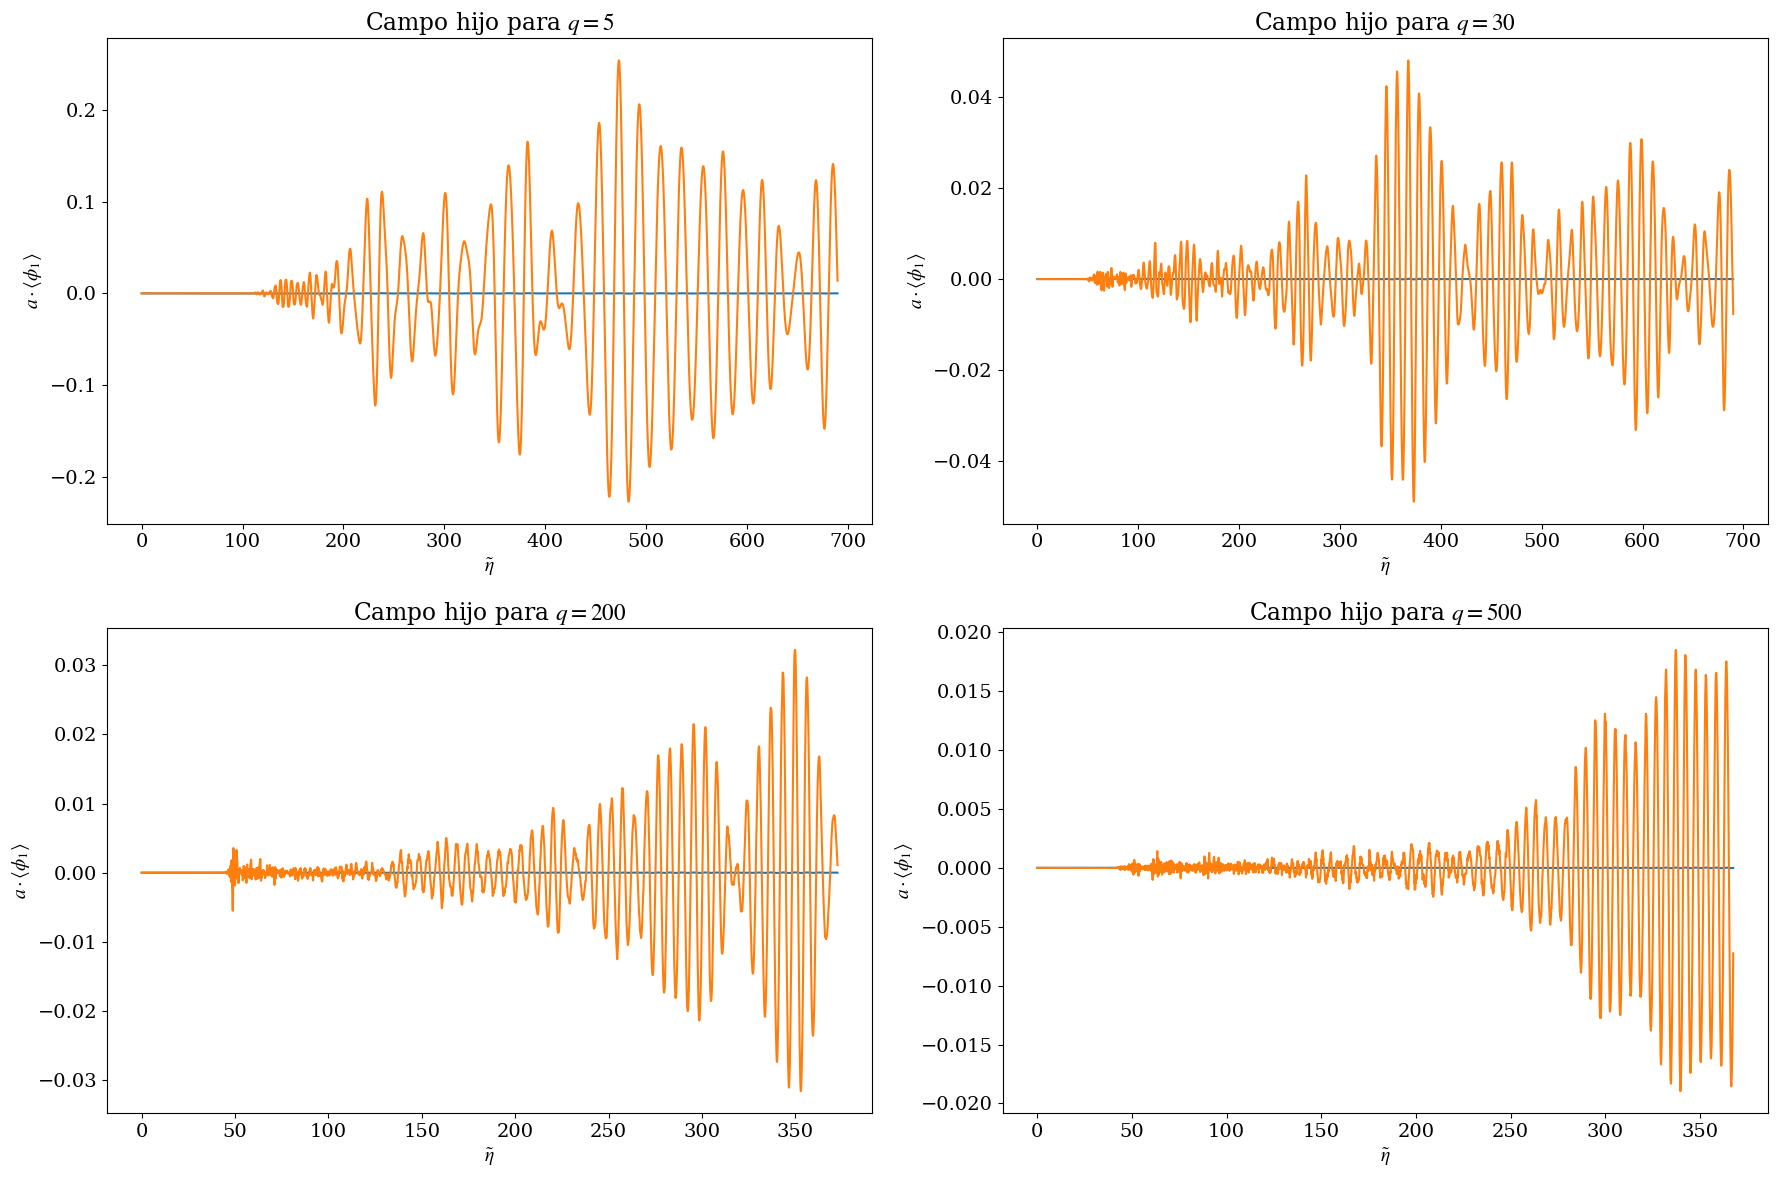

In [6]:
infDatq5 = np.loadtxt(dirq5 + "average_scalar_1.txt")
infDatq30 = np.loadtxt(dirq30 + "average_scalar_1.txt")
infDatq200 = np.loadtxt(dirq200 + "average_scalar_1.txt")
infDatq500 = np.loadtxt(dirq500 + "average_scalar_1.txt")

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plot_fld(infDatq5,"1",aDatq5)
plt.title(r'Campo hijo para $q=5$')

plt.subplot(2, 2, 2)
plot_fld(infDatq30,"1",aDatq30)
plt.title(r'Campo hijo para $q=30$')

plt.subplot(2, 2, 3)
plot_fld(infDatq200,"1",aDatq200)
plt.title(r'Campo hijo para $q=200$')

plt.subplot(2, 2, 4)
plot_fld(infDatq500,"1",aDatq500)
plt.title(r'Campo hijo para $q=500$')

plt.tight_layout()
plt.show()

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

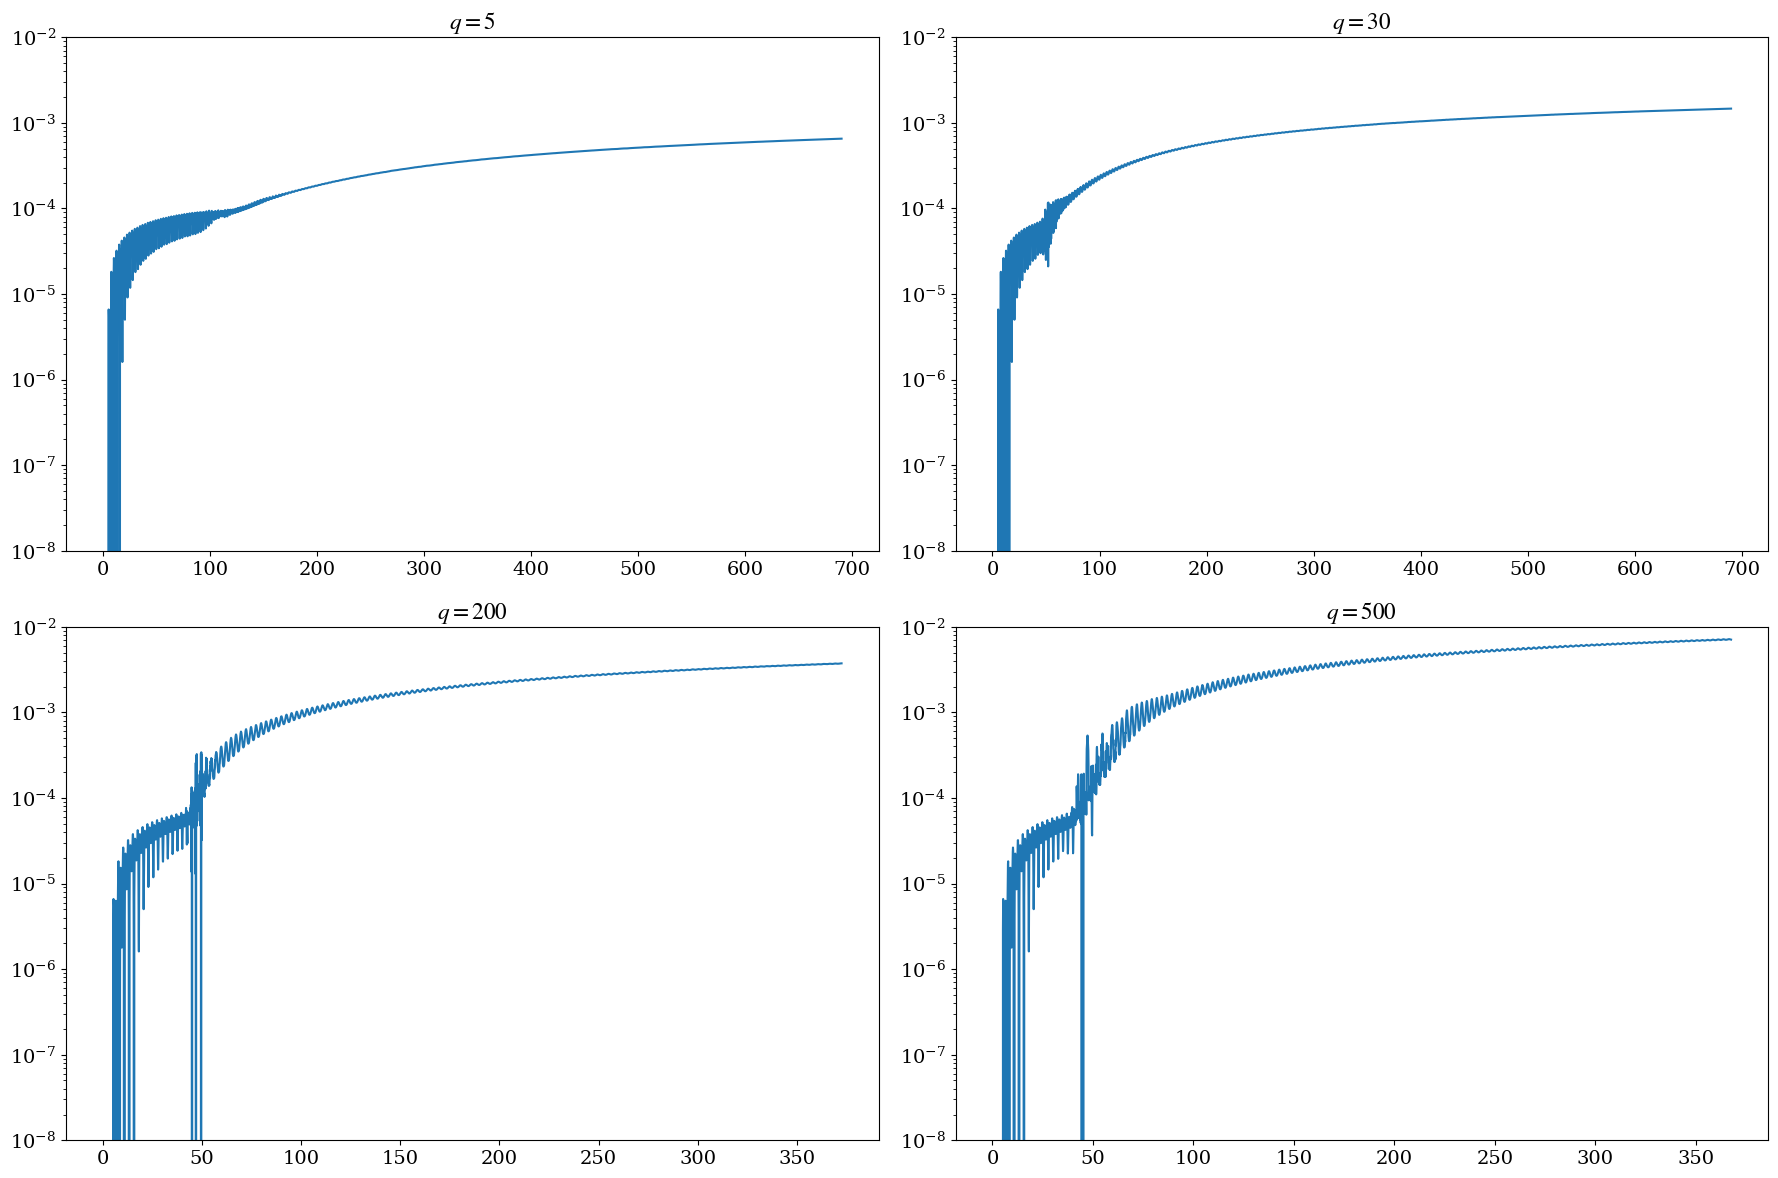

In [7]:
enConsDatq5 = np.loadtxt(dirq5 + "average_energy_conservation.txt")
enConsDatq30 = np.loadtxt(dirq30 + "average_energy_conservation.txt")
enConsDatq200 = np.loadtxt(dirq200 + "average_energy_conservation.txt")
enConsDatq500 = np.loadtxt(dirq500 + "average_energy_conservation.txt")


plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plt.plot(enConsDatq5[:,0], enConsDatq5[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$q=5$')

plt.subplot(2, 2, 2)
plt.plot(enConsDatq30[:,0], enConsDatq30[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$q=30$')

plt.subplot(2, 2, 3)
plt.plot(enConsDatq200[:,0], enConsDatq200[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$q=200$')

plt.subplot(2, 2, 4)
plt.plot(enConsDatq500[:,0], enConsDatq500[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$q=500$')

plt.tight_layout()
plt.show()

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

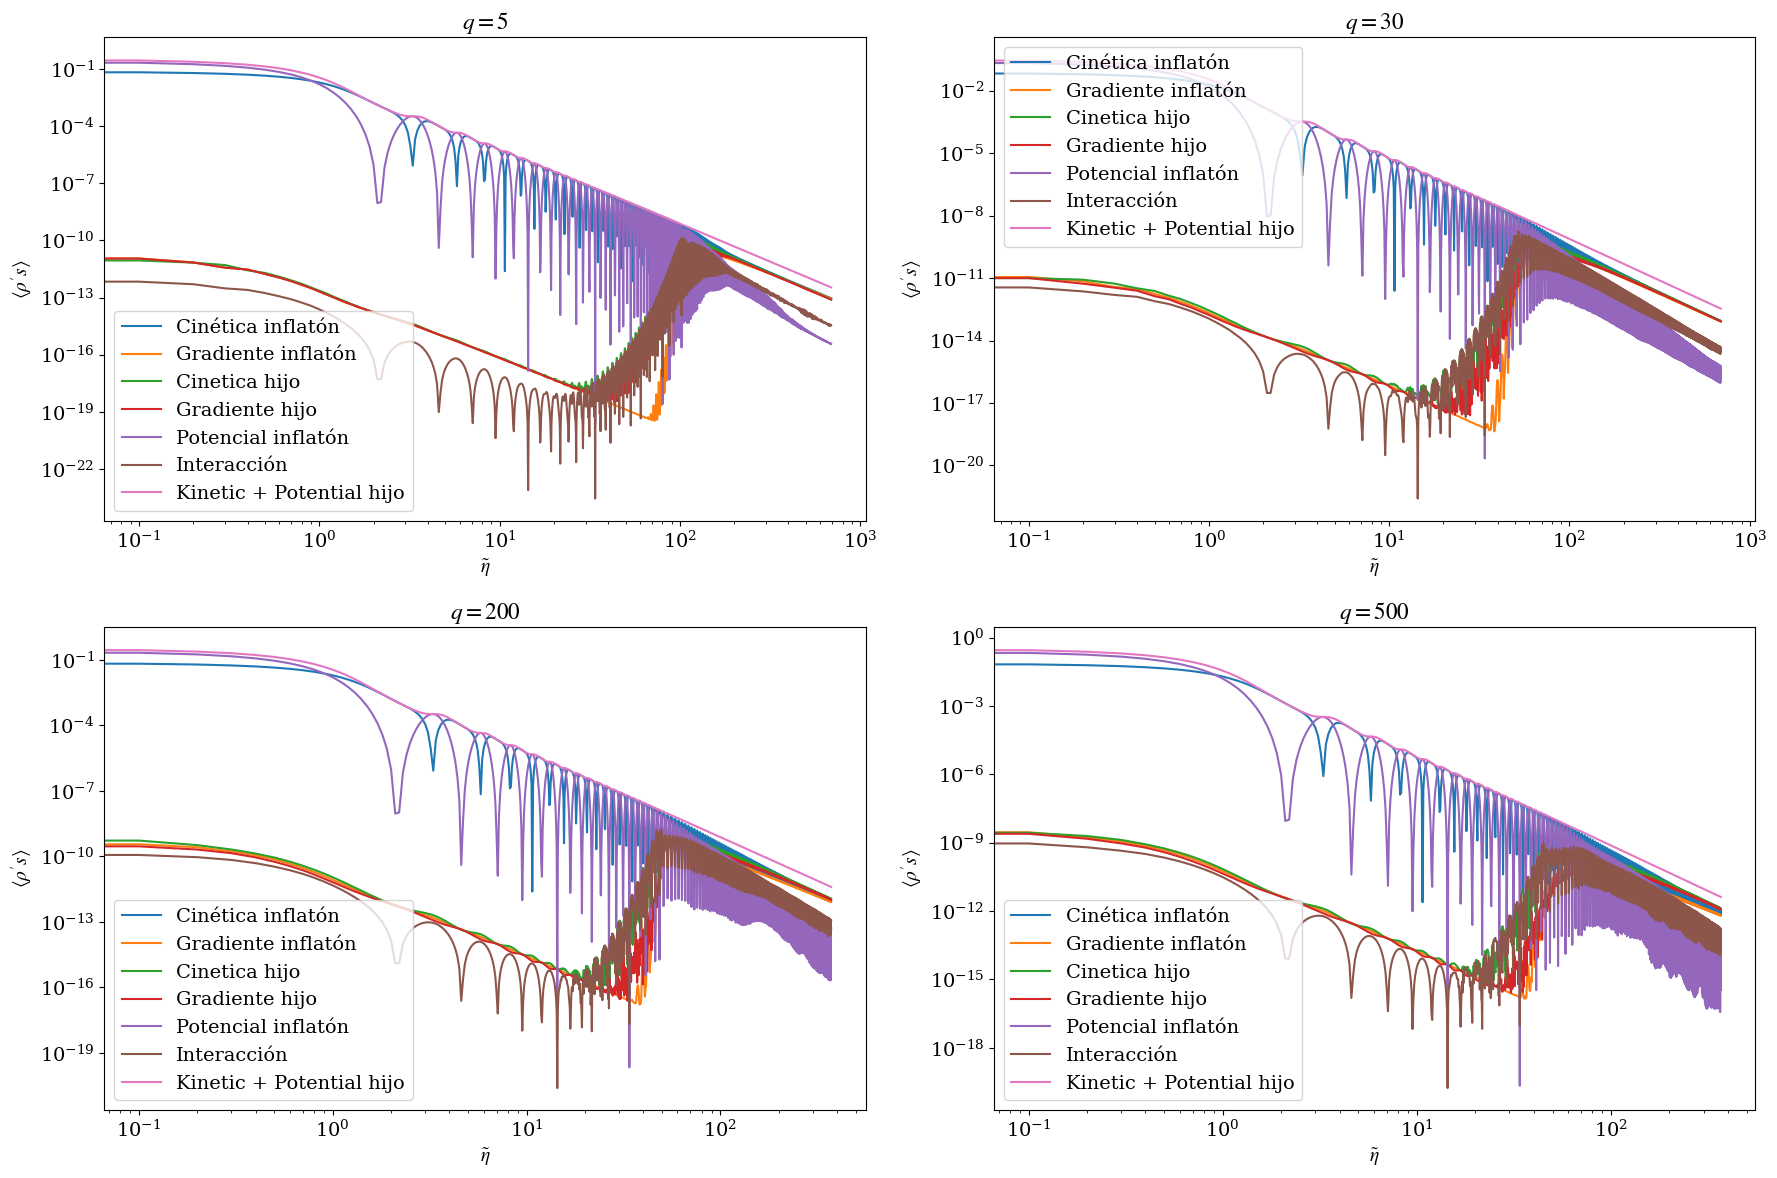

In [8]:
enDatq5 = np.loadtxt(dirq5 + "average_energies.txt")
enDatq30 = np.loadtxt(dirq30 + "average_energies.txt")
enDatq200 = np.loadtxt(dirq200 + "average_energies.txt")
enDatq500 = np.loadtxt(dirq500 + "average_energies.txt")

nColumnsq5 = np.shape(enDatq5)[1]
nColumnsq30 = np.shape(enDatq30)[1]
nColumnsq200 = np.shape(enDatq200)[1]
nColumnsq500 = np.shape(enDatq500)[1]

# set explicitly different colors, so we know who is who
label = ["Cinética inflatón", "Gradiente inflatón", "Cinetica hijo", "Gradiente hijo", "Potencial inflatón", "Interacción", "Kinetic + Potential hijo"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
for i in range(1,nColumnsq5):
    plt.plot(enDatq5[:,0], enDatq5[:,i], color = colors[i-1], label = label[i-1])
plt.title(r'$q=5$')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")
plt.legend()

plt.subplot(2, 2, 2)
for i in range(1,nColumnsq30):
    plt.plot(enDatq30[:,0], enDatq30[:,i], color = colors[i-1], label = label[i-1])
plt.title(r'$q=30$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")
plt.legend()

plt.subplot(2, 2, 3)
for i in range(1,nColumnsq200):
    plt.plot(enDatq200[:,0], enDatq200[:,i], color = colors[i-1], label = label[i-1])
plt.title(r'$q=200$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")
plt.legend()

plt.subplot(2, 2, 4)
for i in range(1,nColumnsq500):
    plt.plot(enDatq500[:,0], enDatq500[:,i], color = colors[i-1], label = label[i-1])
plt.title(r'$q=500$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")
plt.legend()

plt.tight_layout()
plt.show()    

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [ ]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap='plasma'):
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=(nSpectra-1)*10)
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])

    for i in range(nSpectra):
        plt.plot(
            spectra[i*nBins:(i+1)*nBins, 0],
            spectra[i*nBins:(i+1)*nBins, column],
            color=colors(i/nSpectra)
        )
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel('$\\tilde k$', fontsize=20, labelpad=5)

    # Agrega la barra de colores asociada al eje actual
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
    cbar.set_label(r'$t$', fontsize=20, rotation=10)
    cbar.ax.tick_params(labelsize=16)

## Inflaton

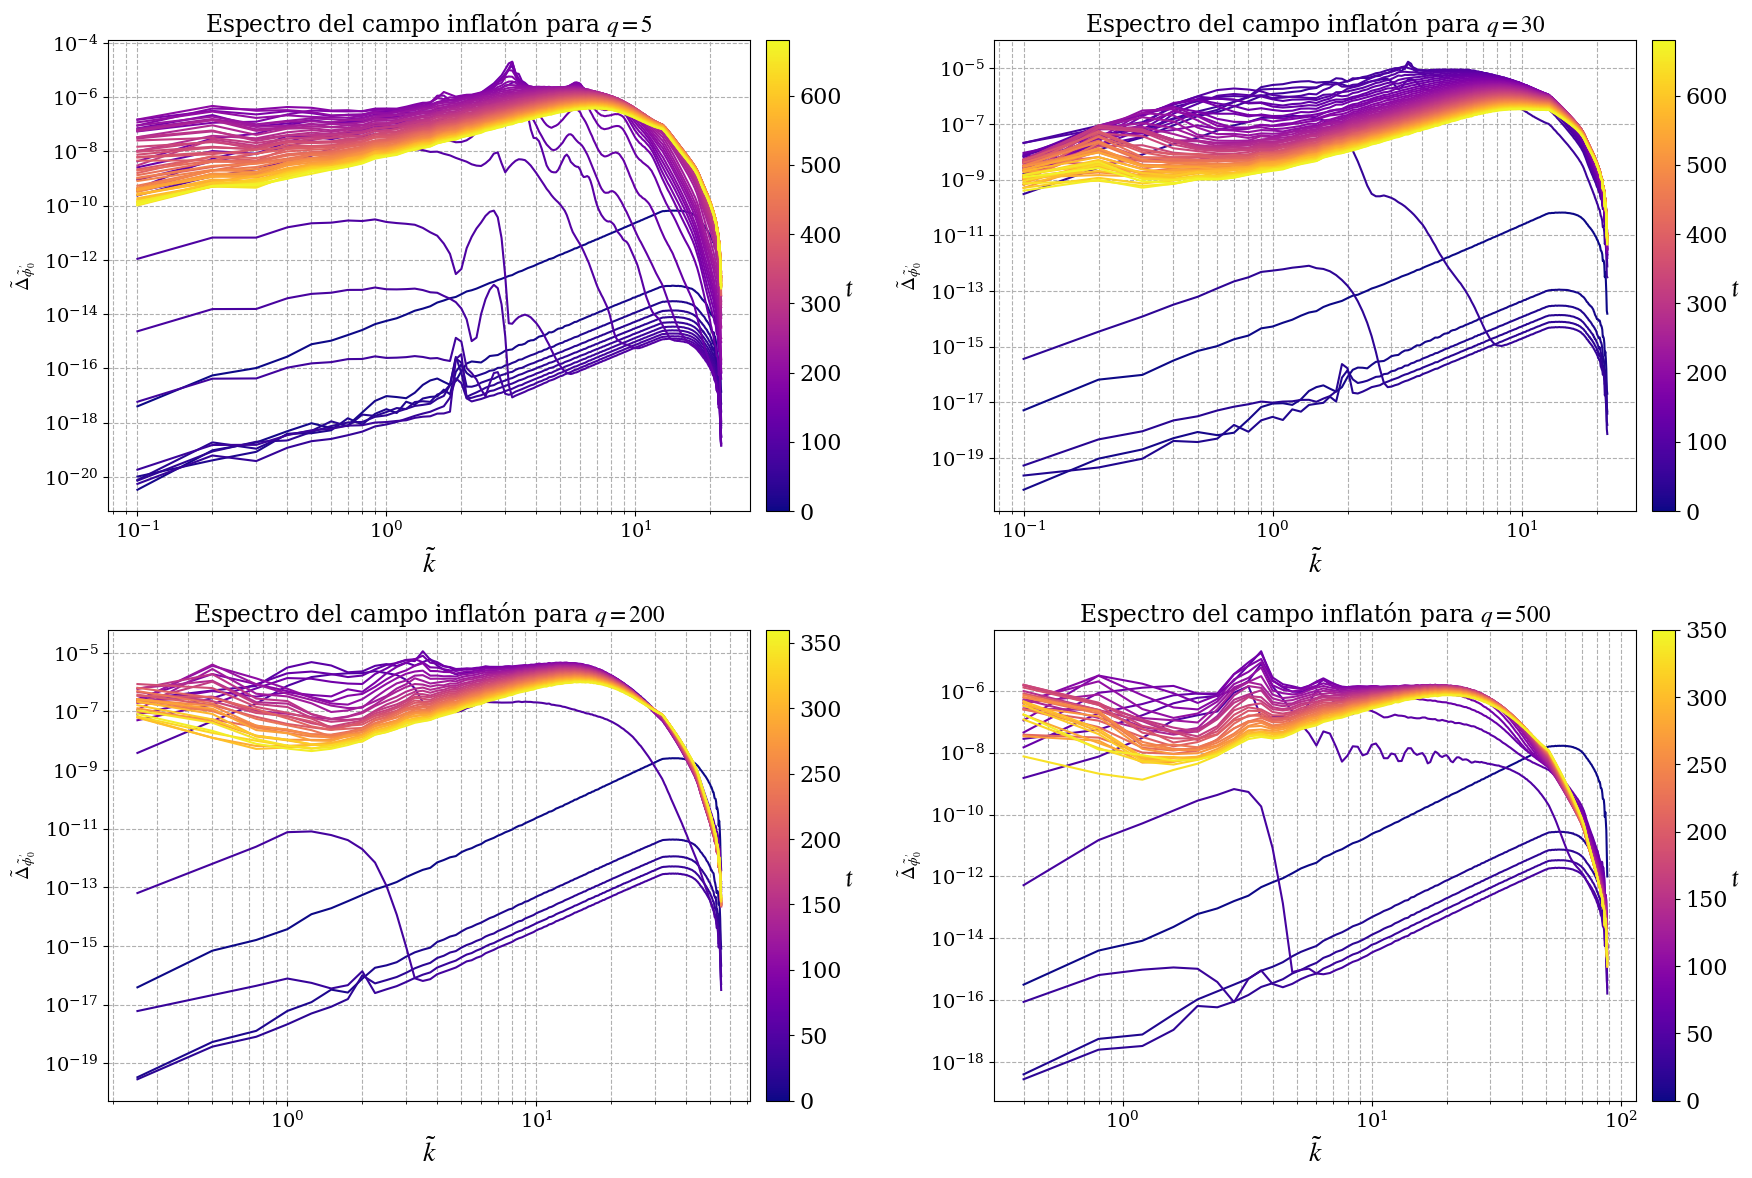

In [10]:
infSpq5, nBinsq5, nSpectraq5 = load_spectrum(dirq5 + "spectra_scalar_0.txt")
infSpq30, nBinsq30, nSpectraq30 = load_spectrum(dirq30 + "spectra_scalar_0.txt")
infSpq200, nBinsq200, nSpectraq200 = load_spectrum(dirq200 + "spectra_scalar_0.txt")
infSpq500, nBinsq500, nSpectraq500 = load_spectrum(dirq500 + "spectra_scalar_0.txt")

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plot_spectrum(infSpq5, 2,  nBinsq5, nSpectraq5)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $q=5$')

plt.subplot(2, 2, 2)
plot_spectrum(infSpq30, 2,  nBinsq30, nSpectraq30)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $q=30$')

plt.subplot(2, 2, 3)
plot_spectrum(infSpq200, 2,  nBinsq200, nSpectraq200)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $q=200$')

plt.subplot(2, 2, 4)
plot_spectrum(infSpq500, 2,  nBinsq500, nSpectraq500)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $q=500$')

plt.tight_layout()
plt.show()

## Daughter field

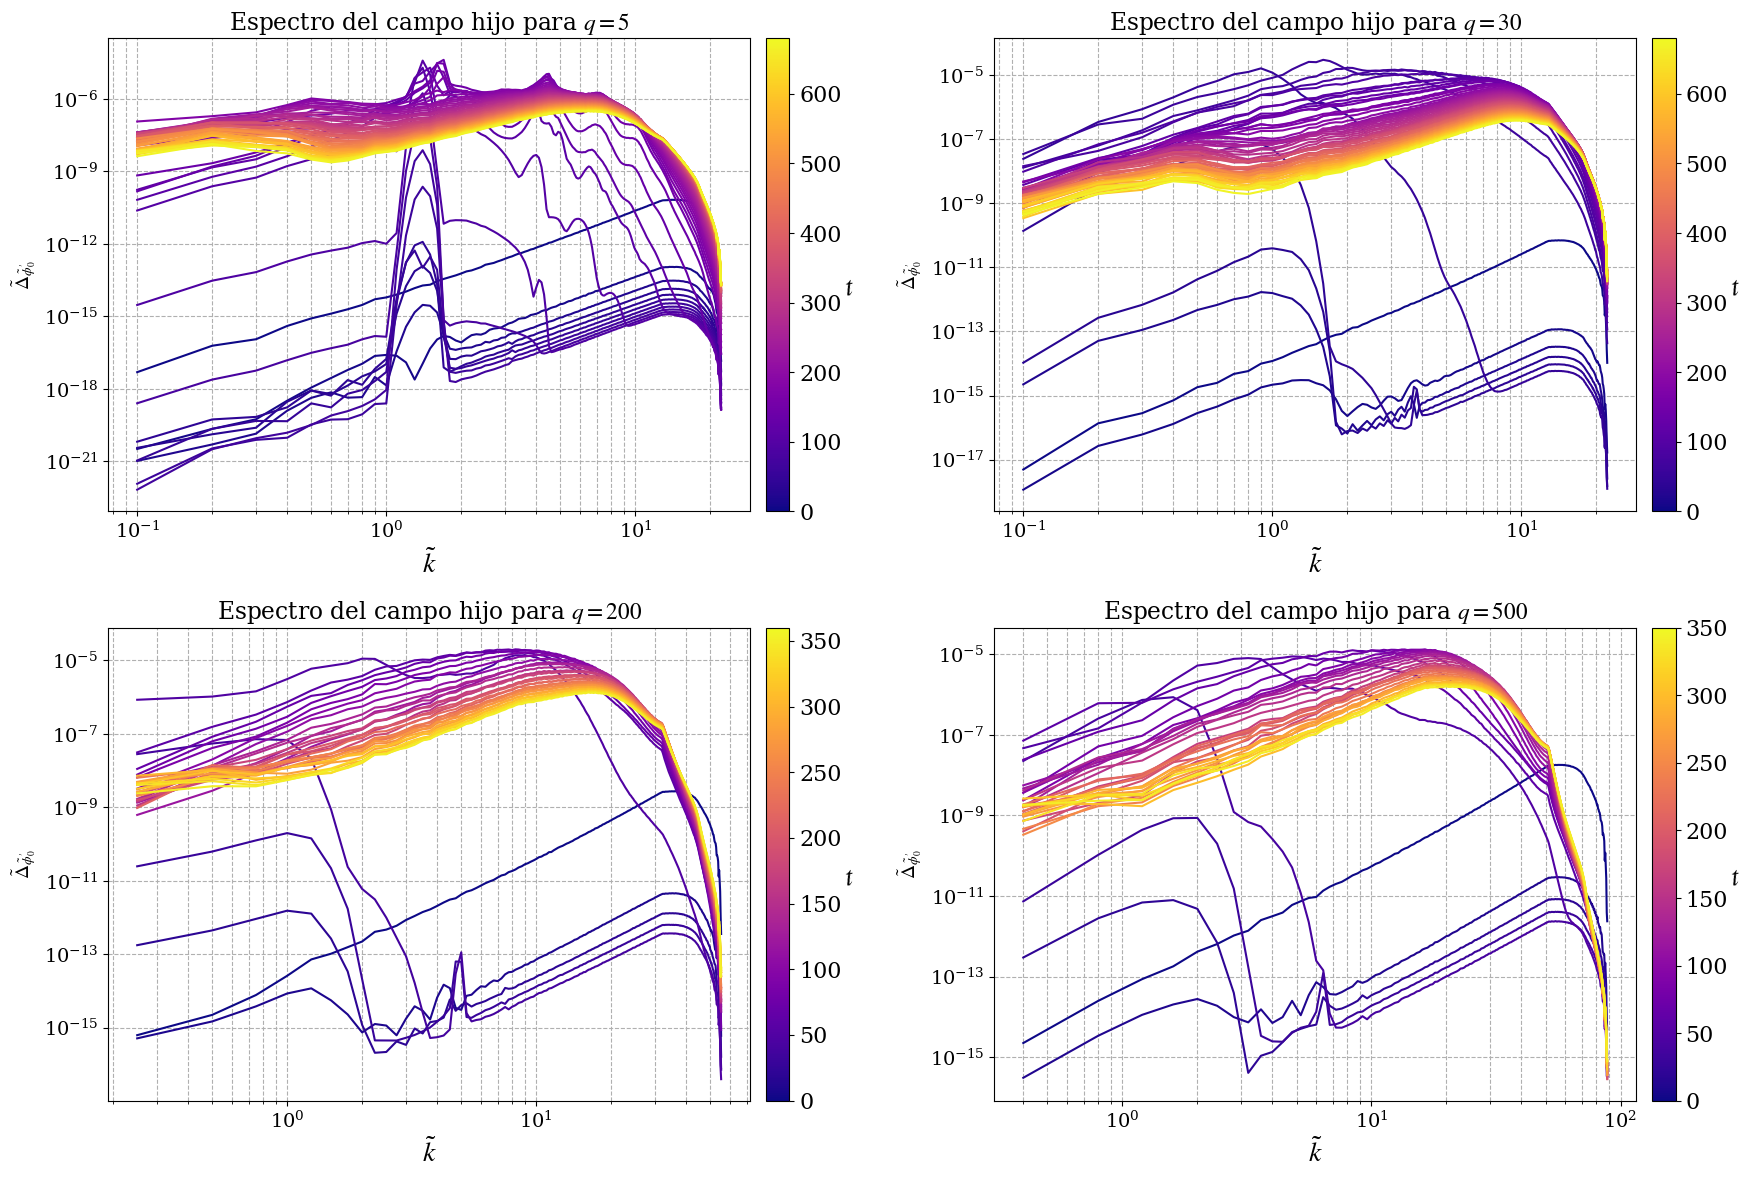

In [11]:
infSpq5, nBinsq5, nSpectraq5 = load_spectrum(dirq5 + "spectra_scalar_1.txt")
infSpq30, nBinsq30, nSpectraq30 = load_spectrum(dirq30 + "spectra_scalar_1.txt")
infSpq200, nBinsq200, nSpectraq200 = load_spectrum(dirq200 + "spectra_scalar_1.txt")
infSpq500, nBinsq500, nSpectraq500 = load_spectrum(dirq500 + "spectra_scalar_1.txt")

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plot_spectrum(infSpq5, 2,  nBinsq5, nSpectraq5)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $q=5$')

plt.subplot(2, 2, 2)
plot_spectrum(infSpq30, 2,  nBinsq30, nSpectraq30)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $q=30$')

plt.subplot(2, 2, 3)
plot_spectrum(infSpq200, 2,  nBinsq200, nSpectraq200)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $q=200$')

plt.subplot(2, 2, 4)
plot_spectrum(infSpq500, 2,  nBinsq500, nSpectraq500)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $q=500$')

plt.tight_layout()
plt.show()

# GWs

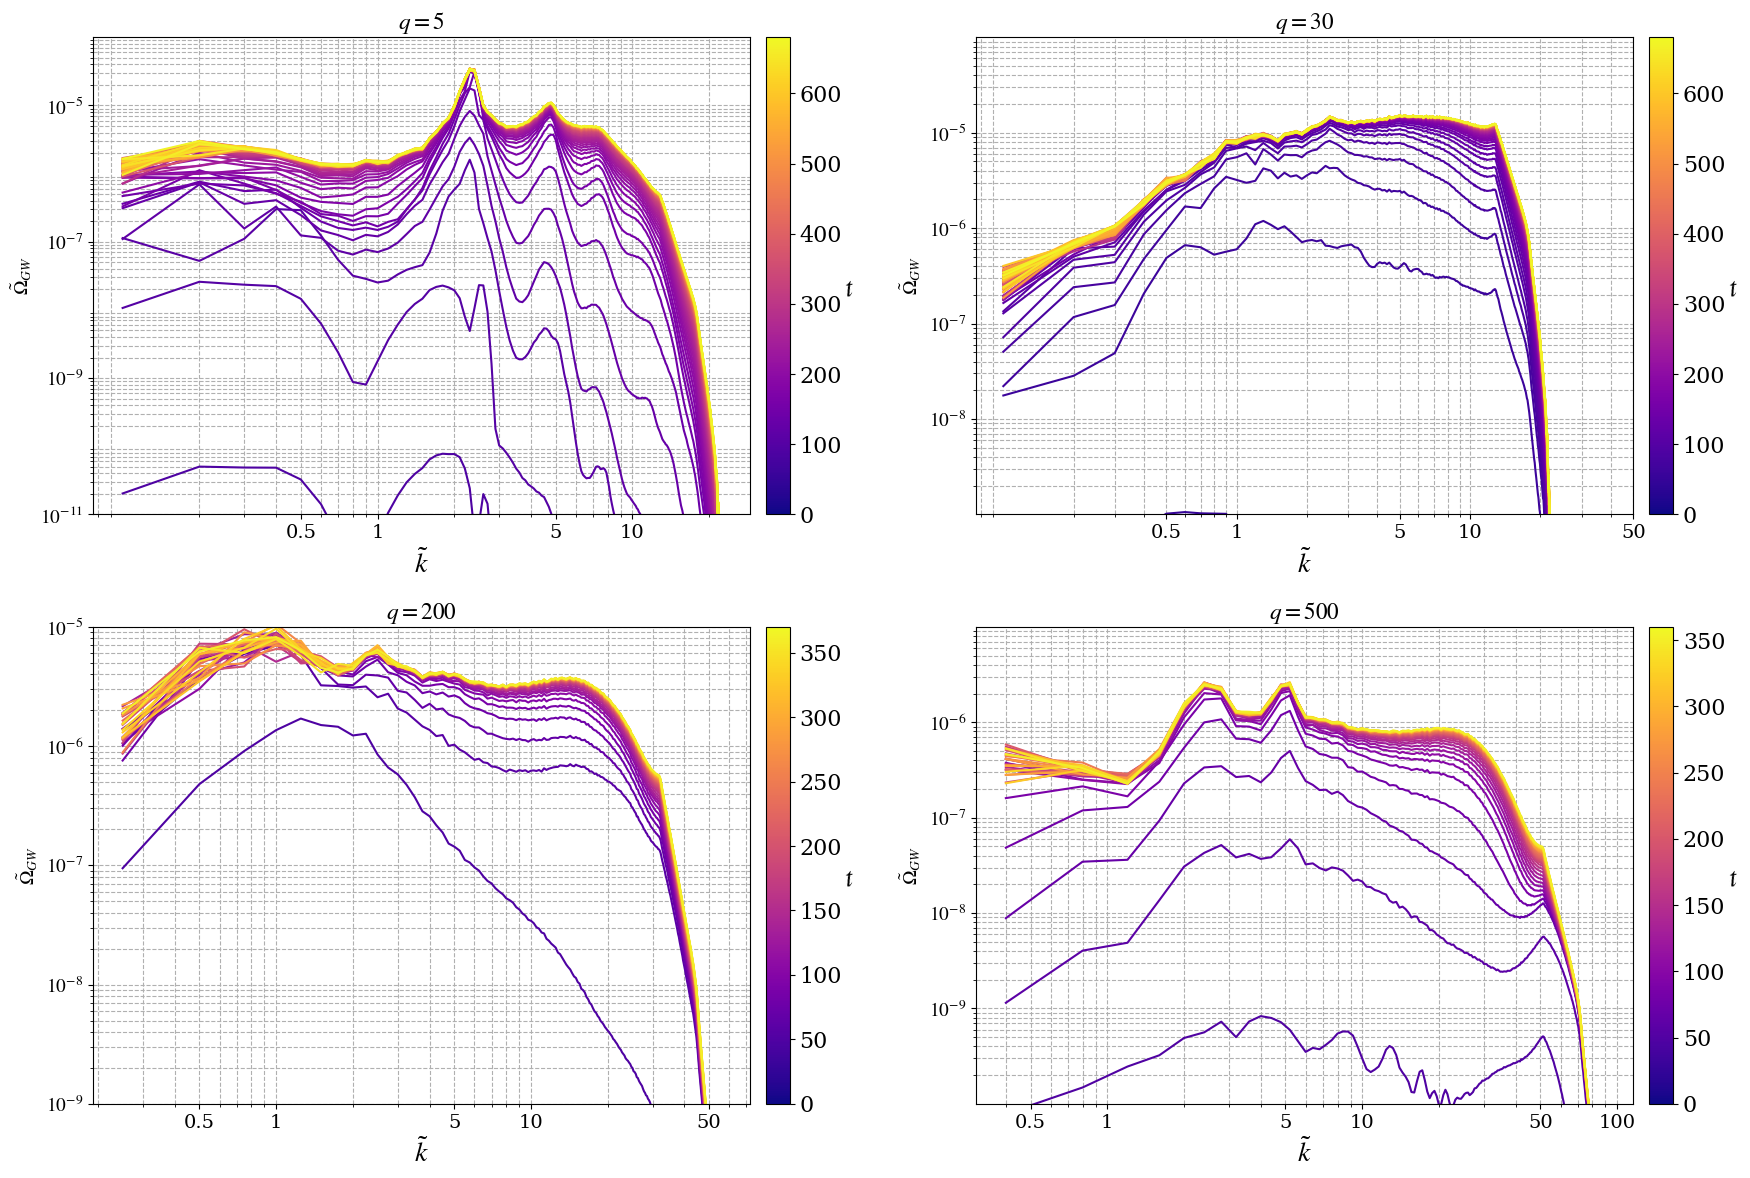

In [12]:
gwSpq5, nBinsq5, nSpectraq5 = load_spectrum(dirq5 + "spectra_gws.txt")
gwSpq30, nBinsq30, nSpectraq30 = load_spectrum(dirq30 + "spectra_gws.txt")
gwSpq200, nBinsq200, nSpectraq200 = load_spectrum(dirq200 + "spectra_gws.txt")
gwSpq500, nBinsq500, nSpectraq500 = load_spectrum(dirq500 + "spectra_gws.txt")

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plot_spectrum(gwSpq5, 1,  nBinsq5, nSpectraq5)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$q=5$')
plt.xticks([0.5,1,5,10], ['0.5','1','5','10'])
plt.yticks([1e-11,1e-9,1e-7,1e-5], [r'$10^{-11}$',r'$10^{-9}$',r'$10^{-7}$',r'$10^{-5}$'])
plt.ylim([1e-11,1e-4])

plt.subplot(2, 2, 2)
plot_spectrum(gwSpq30, 1,  nBinsq30, nSpectraq30)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$q=30$')
plt.xticks([0.5,1,5,10,50], ['0.5','1','5','10','50'])
plt.yticks([1e-8,1e-7,1e-6,1e-5], [r'$10^{-8}$',r'$10^{-7}$',r'$10^{-6}$',r'$10^{-5}$'])
plt.ylim([1e-9,1e-4])


plt.subplot(2, 2, 3)
plot_spectrum(gwSpq200, 1,  nBinsq200, nSpectraq200)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$q=200$')
plt.xticks([0.5,1,5,10,50], ['0.5','1','5','10','50'])
plt.yticks([1e-9,1e-8,1e-7,1e-6,1e-5], [r'$10^{-9}$',r'$10^{-8}$',r'$10^{-7}$',r'$10^{-6}$',r'$10^{-5}$'])
plt.ylim([1e-9,1e-5])

plt.subplot(2, 2, 4)
plot_spectrum(gwSpq500, 1,  nBinsq500, nSpectraq500)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$q=500$')
plt.xticks([0.5,1,5,10,50,100], ['0.5','1','5','10','50','100'])
plt.yticks([1e-9,1e-8,1e-7,1e-6], [r'$10^{-9}$',r'$10^{-8}$',r'$10^{-7}$',r'$10^{-6}$'])
plt.ylim([1e-10,1e-5])

plt.tight_layout()
plt.show()